 # Trajectory analysis
 
This notebook is created to analyse the trajectory case series of the `SCENES` project.

In [1]:
import os
import re
import datetime
import math
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from matplotlib.cm import get_cmap
from matplotlib import rcParams
from cmcrameri import cm     #Scientific color maps
from itertools import cycle
from scipy.stats import ttest_1samp
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import csv 
import random
from IPython.display import display, Markdown
import inspect

In [2]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [3]:
# Set default font properties
rcParams['font.family'] = 'Arial'
# Disable LaTeX rendering for text
rcParams['text.usetex'] = False  # This prevents LaTeX formatting in the tick labels
rcParams['font.size'] = 12

In [4]:
# Root path- project directory
root_dir = os.path.abspath("..")

In [5]:
# Color palettes

# Choose the color palette from cmcrameri
cmap = cm.batlow
cmap_blues = plt.colormaps["Blues"] 

# Define the custom color palette for photoreceptors
photoreceptor_colors = {
    'L cones': (0.8941, 0.1020, 0.1098),
    'M cones': (0.3020, 0.6863, 0.2902),
    'S cones': (0.2157, 0.4941, 0.7216),
    'Rods': (0.0157, 0.4118, 0.3333),
    'Melanopsin': (0.1255, 0.6549, 0.7686)   
}

In [7]:
# Create and save data tree for measurement folder

output_file = os.path.join("../results/datatree.txt")

lines = []

for dirpath, dirnames, filenames in os.walk(root_dir):
    # Skip hidden folders and files (like .git, .ipynb_checkpoints, etc.)
    dirnames[:] = [d for d in sorted(dirnames) if not d.startswith('.')]
    filenames = [f for f in sorted(filenames) if not f.startswith('.')]

    rel_path = os.path.relpath(dirpath, root_dir)
    depth = 0 if rel_path == "." else rel_path.count(os.sep) + 1
    indent = "│   " * (depth - 1)

    # Folder name
    folder_name = os.path.basename(dirpath) if rel_path != "." else os.path.basename(os.path.normpath(root_dir))
    lines.append(f"{indent}{folder_name}/")

    # Files inside folder
    for i, file in enumerate(filenames):
        connector = "└── " if i == len(filenames) - 1 else "├── "
        lines.append(f"{indent}    {connector}{file}")

tree_text = "\n".join(lines)

# Save to file
with open(output_file, "w", encoding="utf-8") as f:
    f.write(tree_text)
    


## Import Jeti-metadata file


In [8]:
# Data frame for merged metadata and jeti/klein df
merged_metadata_jeti_df = pd.read_csv(r'..\data\metadata_jeti_scenes.csv', index_col=0, dtype={'time': str})

# Replace all NaN cells with blanks
merged_metadata_jeti_df = merged_metadata_jeti_df.fillna('')


In [9]:
merged_metadata_jeti_df.head()

,timestamp,project_id,project_name,project_start,data_curator,project_record,setup,device_geometry,measurement_id,record_id,date_x,time_x,protocol,available_$device,available_gloptic_spectis1,available_gigahertz-optic_msc15,available_jeti_spectraval1511,available_westborophotonics_wp690e-circ,wp690csv,available_kleininstruments_k-10a,available_inteldrealsense_d455,available_gopro_hero10black_video,available_gopro_hero10black_photo,location,latitude,longitude,direction,elevation,groundheight,boxtilt,boxheight,temperature,humidity,weather,other_weather,wind,scene,other_scene,view,other_view,lighting,other_lighting,technotes,available_all,date_y,time_y,Illuminance [lx] (CIE1931 2°),Irradiance [W/sqm] (380-780nm),Correlated Color Temp. (CCT) [K],Duv,dE2000 (CIE1931 2°),Dominant Wavelength (DWl) [nm] (CIE1931 2°),Color Purity (PE) [%] (CIE1931 2°),x,y,X,Y,Z,dE00,CCT [K],R1,R2,R3,R4,R5,R6,R7,R8,R9,R10,R11,R12,R13,R14,Ra,Re,DC,VS1,VS2,VS3,VS4,VS5,VS6,VS7,VS8,VS9,VS10,VS11,VS12,VS13,VS14,VS15,Qa,Qf,Qp,Qg,Rf,Rg,Rf (general color fidelity index),Rf1,Rf2,Rf3,Rf4,Rf5,Rf6,Rf7,Rf8,Rf9,Rf10,Rf11,Rf12,Rf13,Rf14,Rf15,Rf16,Rf17,Rf18,Rf19,Rf20,Rf21,Rf22,Rf23,Rf24,Rf25,Rf26,Rf27,Rf28,Rf29,Rf30,Rf31,Rf32,Rf33,Rf34,Rf35,Rf36,Rf37,Rf38,Rf39,Rf40,Rf41,Rf42,Rf43,Rf44,Rf45,Rf46,Rf47,Rf48,Rf49,Rf50,Rf51,Rf52,Rf53,Rf54,Rf55,Rf56,Rf57,Rf58,Rf59,Rf60,Rf61,Rf62,Rf63,Rf64,Rf65,Rf66,Rf67,Rf68,Rf69,Rf70,Rf71,Rf72,Rf73,Rf74,Rf75,Rf76,Rf77,Rf78,Rf79,Rf80,Rf81,Rf82,Rf83,Rf84,Rf85,Rf86,Rf87,Rf88,Rf89,Rf90,Rf91,Rf92,Rf93,Rf94,Rf95,Rf96,Rf97,Rf98,Rf99,Begin Wavelength [nm],End Wavelength [nm],Ephot (Begin..End) [uMol/s sqm],"X e,mel [W/sqm]","X v,mel,D65 (MEDI) [lx]","a mel,v (MEER)","m v,mel,D65 (MDER)",EML [lx],CCT [K].1,Esc [W/sqm],Emc [W/sqm],Elc [W/sqm],Erh [W/sqm],Emel [W/sqm],Peak Wavelength [nm],PEAK FWHM [nm],Centroid Wavelength [nm],R,G,B,Ratio Value,Mv [380; 780],dE1,dE2,dE3,dE4,dE5,Result of relevant equation,Effective Irradiance [mW/sqm],Damage Potential [W/sqm*lx],Maximum exposure time [h],Eb [W/m²],"Kb,v [W/lm]",Kc,R bp/fs [%],R lb/tb [%],R nbp/bp [%]
0,20230208T0800,101,SCENES,20230208,Niloufar Tabandeh,1.0,Full setup,,1001,1001_20230208T0800,20230208,800,Timelapse,,0,0,1,1,1,1,1,1,1,Tübingen-DE,48.537222,9.058611,120SE,460,4,0,130,-3.5,55.1,Clear,,No wind,Outdoor (countryside),,Outdoor,,Outdoor (daylight),,,2,20230208,800,12728.4,86.5,2899.0,0.000,25.4,583.2,55.6,0.445,0.407,13902.0,12728.0,4637.0,131.8,2899.4,91.9,96.4,96.9,91.4,92.5,96.2,93.9,86.2,71.7,93.1,90.4,94.3,92.4,98.1,93.2,91.8,0.0,97.8,93.3,93.4,95.5,96.5,95.1,96.9,98.4,96.1,94.7,94.9,97.5,93.6,97.0,97.8,95.6,94.3,98.2,102.5,95.0,101.5,95.0,96.0,93.1,93.8,94.2,89.2,92.5,91.8,90.0,98.9,91.8,89.2,90.6,94.7,97.7,95.0,91.0,90.8,94.6,91.9,90.5,91.7,90.9,96.9,94.7,92.9,93.5,96.6,98.1,93.7,94.4,94.5,93.5,95.4,96.9,98.7,96.7,98.7,95.2,99.2,98.5,97.6,97.9,95.9,99.8,96.3,95.7,96.6,92.4,96.2,97.0,97.3,96.6,95.5,96.5,96.7,95.1,94.9,95.4,96.6,98.8,96.9,97.6,97.3,94.6,94.3,94.9,94.7,95.2,97.0,94.7,96.1,98.1,94.2,97.6,96.8,94.7,95.6,95.9,96.4,96.8,89.4,98.7,97.4,97.9,94.1,89.6,95.0,94.3,92.7,94.2,97.2,91.5,94.0,89.4,93.7,94.9,93.7,94.0,92.1,400.0,700.0,271.5,8.8,6658.9,0.5,0.5,7348.2,2899.4,3.3,15.1,21.1,11.1,8.8,777.0,83340.0,746.1,19320.4,11408.5,4566.1,0.5,2.9,3.1,3.4,2.0,4.6,1.6,0.0,35.1,0.0,142.6,4.0,0.000,0.5,5.1,29.1,451.6
1,20230208T0830,101,SCENES,20230208,Niloufar Tabandeh,2.0,Full setup,,1001,1001_20230208T0830,20230208,830,Timelapse,,0,0,1,0,0,1,1,1,1,Tübingen-DE,48.537222,9.058611,120SE,460,4,0,130,-2.1,50.8,Clear,,No wind,Outdoor (countryside),,Outdoor,,Outdoor (daylight),,,1,20230208,830,44447.0,227.6,3910.0,0.005,19.8,577.0,34.7,0.389,0.393,43913.0,44447.0,24647.0,134.0,3910.2,98.8,98.3,98.1,96.3,98.7,98.4,96.0,96.0,93.4,97.2,97.2,93.5,98.0,99.1,97.6,97.1,0.0,99.2,94.6,93.1,90.3,92.4,92.6,94.6,95.4,98.2,98.2,96.1,94.9,94.0,97.0,98.5,94.7,94.8,94.6,97.4,94.9,97.7,94.9,98.2,96.7,95.0,96.0,94.8,97.6,97.8,97.1,98.4,95.9,94.8,95.5,97.0,98.4,94.3,94.0,93.6,94.4,93.9,89.1,93.2,90.9,95.7,94.4,9

## Trajectory data frame, measured sequences

In [10]:
trajectory_canada_df = merged_metadata_jeti_df[
    (merged_metadata_jeti_df['protocol'] == 'Trajectory') &
    (merged_metadata_jeti_df['location'] == 'Ottawa-CA')
]
trajectory_canada_df.shape

(63, 235)

In [11]:
trajectory_canada_df.head()


,timestamp,project_id,project_name,project_start,data_curator,project_record,setup,device_geometry,measurement_id,record_id,date_x,time_x,protocol,available_$device,available_gloptic_spectis1,available_gigahertz-optic_msc15,available_jeti_spectraval1511,available_westborophotonics_wp690e-circ,wp690csv,available_kleininstruments_k-10a,available_inteldrealsense_d455,available_gopro_hero10black_video,available_gopro_hero10black_photo,location,latitude,longitude,direction,elevation,groundheight,boxtilt,boxheight,temperature,humidity,weather,other_weather,wind,scene,other_scene,view,other_view,lighting,other_lighting,technotes,available_all,date_y,time_y,Illuminance [lx] (CIE1931 2°),Irradiance [W/sqm] (380-780nm),Correlated Color Temp. (CCT) [K],Duv,dE2000 (CIE1931 2°),Dominant Wavelength (DWl) [nm] (CIE1931 2°),Color Purity (PE) [%] (CIE1931 2°),x,y,X,Y,Z,dE00,CCT [K],R1,R2,R3,R4,R5,R6,R7,R8,R9,R10,R11,R12,R13,R14,Ra,Re,DC,VS1,VS2,VS3,VS4,VS5,VS6,VS7,VS8,VS9,VS10,VS11,VS12,VS13,VS14,VS15,Qa,Qf,Qp,Qg,Rf,Rg,Rf (general color fidelity index),Rf1,Rf2,Rf3,Rf4,Rf5,Rf6,Rf7,Rf8,Rf9,Rf10,Rf11,Rf12,Rf13,Rf14,Rf15,Rf16,Rf17,Rf18,Rf19,Rf20,Rf21,Rf22,Rf23,Rf24,Rf25,Rf26,Rf27,Rf28,Rf29,Rf30,Rf31,Rf32,Rf33,Rf34,Rf35,Rf36,Rf37,Rf38,Rf39,Rf40,Rf41,Rf42,Rf43,Rf44,Rf45,Rf46,Rf47,Rf48,Rf49,Rf50,Rf51,Rf52,Rf53,Rf54,Rf55,Rf56,Rf57,Rf58,Rf59,Rf60,Rf61,Rf62,Rf63,Rf64,Rf65,Rf66,Rf67,Rf68,Rf69,Rf70,Rf71,Rf72,Rf73,Rf74,Rf75,Rf76,Rf77,Rf78,Rf79,Rf80,Rf81,Rf82,Rf83,Rf84,Rf85,Rf86,Rf87,Rf88,Rf89,Rf90,Rf91,Rf92,Rf93,Rf94,Rf95,Rf96,Rf97,Rf98,Rf99,Begin Wavelength [nm],End Wavelength [nm],Ephot (Begin..End) [uMol/s sqm],"X e,mel [W/sqm]","X v,mel,D65 (MEDI) [lx]","a mel,v (MEER)","m v,mel,D65 (MDER)",EML [lx],CCT [K].1,Esc [W/sqm],Emc [W/sqm],Elc [W/sqm],Erh [W/sqm],Emel [W/sqm],Peak Wavelength [nm],PEAK FWHM [nm],Centroid Wavelength [nm],R,G,B,Ratio Value,Mv [380; 780],dE1,dE2,dE3,dE4,dE5,Result of relevant equation,Effective Irradiance [mW/sqm],Damage Potential [W/sqm*lx],Maximum exposure time [h],Eb [W/m²],"Kb,v [W/lm]",Kc,R bp/fs [%],R lb/tb [%],R nbp/bp [%]
228,20230614T0800,101,SCENES,20230208,Niloufar Tabandeh,229.0,Full setup,,1012,1012_20230614T0800,20230614,800,Trajectory,,0,0,1,1,1,1,1,1,1,Ottawa-CA,45.449167,-75.629722,243SW,100,0,0,116,20.1,63.2,Partially cloudy,,No wind,Indoor (bedroom),,Indoor w/ window,,Indoor (daylight),,wildfire smoke,2,20230614,800,36.1,0.1,3087.0,-0.002,23.4,583.3,47.0,0.428,0.395,39.0,36.1,16.1,57.2,3086.7,93.9,97.6,98.2,92.9,93.8,96.4,91.1,81.4,59.0,93.2,93.5,86.1,95.2,99.3,93.2,90.8,0.0,88.0,92.8,93.3,95.1,99.1,93.4,92.9,94.1,92.7,89.8,89.7,97.0,90.9,94.2,91.1,92.4,92.0,93.7,99.1,92.4,99.2,92.4,96.2,91.9,89.8,93.2,83.0,90.1,88.2,84.4,99.0,90.7,88.9,89.6,92.9,97.9,96.1,87.6,89.5,95.0,92.5,82.4,90.8,91.1,97.4,93.4,90.4,92.8,95.9,96.2,95.3,95.7,95.6,90.3,98.5,94.0,96.7,89.2,96.0,92.9,99.2,97.5,97.9,95.3,93.2,99.5,96.6,95.7,95.6,93.3,95.3,98.2,98.0,97.3,96.2,95.0,93.8,94.6,93.8,94.0,96.7,94.8,94.1,90.6,93.1,90.9,89.7,89.2,88.5,90.4,92.3,89.0,86.2,95.2,86.3,92.8,87.8,90.5,90.3,89.3,93.8,93.3,84.0,97.0,96.3,96.0,85.0,83.4,92.8,95.5,86.7,96.4,83.9,81.7,88.6,80.4,87.0,92.7,95.9,93.9,90.6,400.0,700.0,0.6,0.0,19.0,0.5,0.5,21.0,3086.7,0.0,0.0,0.1,0.0,0.0,612.0,154.9,604.7,52.5,32.8,16.0,0.2,2.1,2.2,0.9,2.1,3.2,2.0,0.0,0.1,0.0,75790.8,0.0,0.000,0.5,7.7,34.4,202.6
229,20230614T0830,101,SCENES,20230208,Niloufar Tabandeh,230.0,Full setup,,1012,1012_20230614T0830,20230614,830,Trajectory,,0,0,1,1,1,1,1,1,1,Ottawa-CA,45.449167,-75.621944,325NW,100,1,0,116,19.8,52.3,Partially cloudy,,No wind,Indoor (kitchen),,Indoor w/ window,,Indoor (daylight),,wildfire smoke,2,20230614,830,130.2,1.0,4825.0,0.016,20.0,566.6,24.6,0.355,0.394,117.4,130.2,83.2,106.3,4825.2,78.3,84.7,92.0,79.5,77.7,78.6,95.9,78.7,34.5,64.6,72.0,61.4,78.7,95.4,83.2,76.6,0.0,81.8,87.8,89.2,91.3,96.6,89.4,80.0,78.9,82.0,83.3,88.0,98.4,91.0,88.9,85.3,86.3,87.0,83.9,89.2,88.9,93.1,88.9,90.6,82.9,89.9,87.1,78.8,89.2,79.4,79.3,96.5,83.7,85.0,82.2,85.6,94.5,90.1,84.2,88.6,89.6,86.8,84.

In [12]:
copy_trajectory_canada_df = trajectory_canada_df.copy()

# Convert timestamp to datetime
copy_trajectory_canada_df['datetime'] = pd.to_datetime(copy_trajectory_canada_df['timestamp'], format='%Y%m%dT%H%M')
copy_trajectory_canada_df['date'] = copy_trajectory_canada_df['datetime'].dt.date
copy_trajectory_canada_df['time'] = copy_trajectory_canada_df['datetime'].dt.time

metrics = [
    'Illuminance [lx] (CIE1931 2°)',
    'X v,mel,D65 (MEDI) [lx]' 
]

# Pivot table: one row per time, columns = date × metric
pivot_photopic_melanopic_trajectory_canada_df = copy_trajectory_canada_df.pivot_table(
    index='time',      # rows = time only
    columns='date',    # columns = dates
    values=metrics,    # metrics to pivot
    aggfunc='first'     # take the first value for each time/date (we have just one value for each timestamp)
).reset_index()

# Rename metrics
rename_map = {
    'Illuminance [lx] (CIE1931 2°)': 'Photopic illuminance (lux)',
    'X v,mel,D65 (MEDI) [lx]': 'Melanopic-EDI (lux)'
}
pivot_photopic_melanopic_trajectory_canada_df = pivot_photopic_melanopic_trajectory_canada_df.rename(columns=rename_map, level=0)

# Replace NaNs with empty string
pivot_photopic_melanopic_trajectory_canada_df = pivot_photopic_melanopic_trajectory_canada_df.fillna("")
pivot_photopic_melanopic_trajectory_canada_df.to_csv(r'..\results\pivot_photopic_melanopic_trajectory_canada.csv', index=False)
pivot_photopic_melanopic_trajectory_canada_df

time Photopic illuminance (lux)                        \
date                           2023-06-14 2023-06-16 2023-06-19   
0     08:00:00                       36.1       37.3       43.8   
1     08:30:00                      130.2      110.0      114.1   
2     09:00:00                     4553.4    15976.8     6286.0   
3     09:30:00                    15164.0    14620.2    11627.8   
4     09:45:00                     7540.7                         
5     10:00:00                    12543.8    14606.9    12254.8   
6     10:30:00                      464.6      154.2     3768.2   
7     11:00:00                      493.4      154.9     4047.0   
8     11:30:00                      421.9      155.9     4429.0   
9     12:00:00                      379.3      156.7     4311.8   
10    12:30:00                      359.1      156.2     3715.6   
11    13:00:00                     4904.2    15422.8    34813.6   
12    13:30:00                      639.1      941.1     1353.8   
13    14:00:00                      327.5      161.6     6518.5   
14    14:30:00                      279.3      165.1     7671.7   
15    15:00:00                      325.8      165.4     7671.2   
16    15:30:00                      251.5      165.8     8977.6   
17    16:00:00                     5845.9    12023.0     8389.2   
18    16:30:00                     8367.5    15424.6              
19    17:00:00                     1500.3     2813.6              
20    17:30:00                       63.8       27.0       31.4   
21    18:00:00                       37.2       33.4       61.8   
22    18:30:00                       35.9                         

     Melanopic-EDI (lux)                        
date          2023-06-14 2023-06-16 2023-06-19  
0                   19.0       20.4       23.0  
1                   92.0       70.8       81.1  
2                 4227.6    14421.8     6155.2  
3                14287.4    13535.0    10942.8  
4                 7474.6                        
5                11539.1    13503.6    11466.1  
6                  355.0       93.2     3527.1  
7                  378.2       93.5     3858.5  
8                  320.2       93.9     4130.5  
9                  286.4       94.5     4171.3  
10                 269.7       94.3     3421.9  
11                4439.6    14938.9    33750.6  
12                 551.7      845.3     1185.9  
13                 248.2       97.9     6252.4  
14                 207.8       99.9     7325.8  
15                 245.8      100.5     7678.2  
16                 185.7      100.6     8660.9  
17                5553.3    10945.2     7783.4  
18                7709.9    14772.3             
19                1408.0     2715.7             
20                  47.1       22.2       24.2  
21                  18.4       24.4       46.3  
22                  17.5

In [13]:
# Extract date part (first 8 characters: yyyymmdd)

trajectory_canada_dates = copy_trajectory_canada_df['date'].astype(str).unique().tolist()
trajectory_canada_dates

['2023-06-14', '2023-06-16', '2023-06-19']

In [14]:
# Extract time part (last 4 characters: hhdd)

trajectory_canada_times = copy_trajectory_canada_df['time'].astype(str).unique().tolist()
trajectory_canada_times

['08:00:00',
 '08:30:00',
 '09:00:00',
 '09:30:00',
 '09:45:00',
 '10:00:00',
 '10:30:00',
 '11:00:00',
 '11:30:00',
 '12:00:00',
 '12:30:00',
 '13:00:00',
 '13:30:00',
 '14:00:00',
 '14:30:00',
 '15:00:00',
 '15:30:00',
 '16:00:00',
 '16:30:00',
 '17:00:00',
 '17:30:00',
 '18:00:00',
 '18:30:00']

In [15]:
# Create summary table  
grouped_df = copy_trajectory_canada_df.groupby(['date', 'view']).size().reset_index(name='count')

# Create a new column 'type' based on 'view'
grouped_df['index'] = grouped_df['view'].apply(lambda x: 'outdoor' if x == 'Outdoor' else 'indoor')

# Pivot the DataFrame to have 'Outdoor' and 'Indoor' as separate columns
pivot_summary_df = grouped_df.pivot_table(index='date', columns='index', values='count', aggfunc='sum', fill_value=0).reset_index()
# Add a 'Total' column to sum up counts for each date
pivot_summary_df['sum'] = pivot_summary_df[['indoor', 'outdoor']].sum(axis=1)

summary_row = {
    'date': 'total',
    'indoor': pivot_summary_df['indoor'].sum(),
    'outdoor': pivot_summary_df['outdoor'].sum(),
    'sum': pivot_summary_df['sum'].sum()
}
pivot_summary_df = pd.concat(
    [pivot_summary_df, pd.DataFrame([summary_row])],
    ignore_index=True
)
pivot_summary_df.index = pivot_summary_df.index + 1
pivot_summary_df.to_csv(r'..\results\pivot_summary_trajectory_canada.csv', index=False)
pivot_summary_df


,date,indoor,outdoor,sum
1,2023-06-14,16,7,23
2,2023-06-16,14,7,21
3,2023-06-19,15,4,19
4,total,45,18,63


### Photopic illuminance

In [16]:
# Group by time and compute mean, min, max, Q1, Q3, and IQR
photopic_stats = copy_trajectory_canada_df.groupby('time')['Illuminance [lx] (CIE1931 2°)'].agg(
    mean='mean',
    min='min',
    max='max',
    q1=lambda x: x.quantile(0.25),
    q3=lambda x: x.quantile(0.75)
)
# Add IQR column
photopic_stats['iqr'] = photopic_stats['q3'] - photopic_stats['q1']

# Round mean to 2 decimals
photopic_stats['mean'] = photopic_stats['mean'].round(2)

# Reset index if needed
photopic_stats = photopic_stats.reset_index()
photopic_stats

,time,mean,min,max,q1,q3,iqr
0,08:00:00,39.07,36.1,43.8,36.700,40.550,3.85
1,08:30:00,118.10,110.0,130.2,112.050,122.150,10.10
2,09:00:00,8938.73,4553.4,15976.8,5419.700,11131.400,5711.70
3,09:30:00,13804.00,11627.8,15164.0,13124.000,14892.100,1768.10
4,09:45:00,7540.70,7540.7,7540.7,7540.700,7540.700,0.00
5,10:00:00,13135.17,12254.8,14606.9,12399.300,13575.350,1176.05
6,10:30:00,1462.33,154.2,3768.2,309.400,2116.400,1807.00
7,11:00:00,1565.10,154.9,4047.0,324.150,2270.200,1946.05
8,11:30:00,1668.93,155.9,4429.0,288.900,2425.450,2136.55
9,12:00:00,1615.93,156.7,4311.8,268.000,2345.550,2077.55


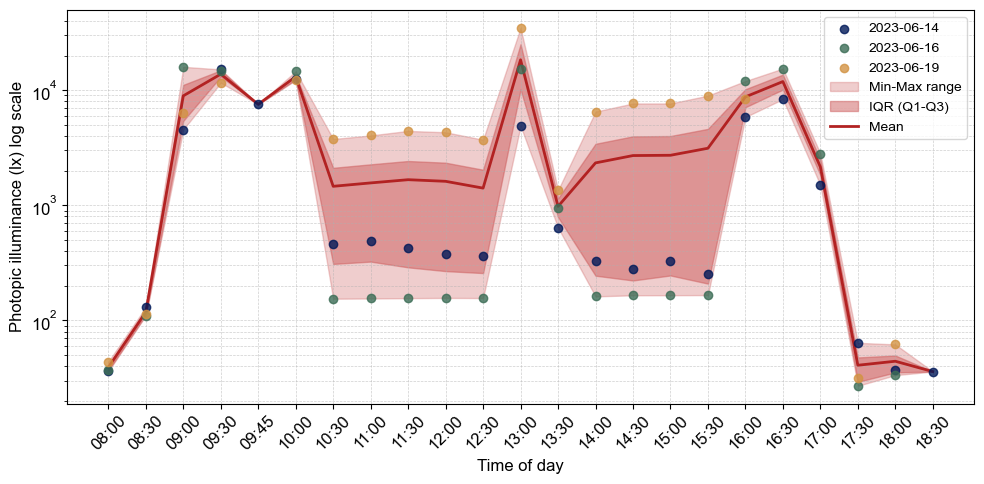

In [18]:
# Plot photopic illuminance for measurement days with central stats
fig, ax = plt.subplots(figsize=(10,5))

scatter_handles = []  # to collect scatter handles for legend
colors = [cm.batlow(i/len(copy_trajectory_canada_df['date'].unique())) for i in range(len(copy_trajectory_canada_df['date'].unique()))]

# Plot each day's measurements as scatter
for i, date in enumerate(copy_trajectory_canada_df['date'].unique()):
    day_data = copy_trajectory_canada_df[copy_trajectory_canada_df['date'] == date]
    sc = ax.scatter(
        [t.strftime('%H:%M') if not isinstance(t, str) else t[:5] for t in day_data['time']],
        day_data['Illuminance [lx] (CIE1931 2°)'],
        color=colors[i],
        alpha=0.8,
        zorder=4
    )
    scatter_handles.append((sc, str(date)))  # store handle + label

# Fill area between Q1 and Q3 (IQR)
iqr_fill = ax.fill_between(
    [t.strftime('%H:%M') for t in photopic_stats['time']],
    photopic_stats['q1'],
    photopic_stats['q3'],
    color='indianred',
    alpha=0.5,
    zorder=1,
    label='IQR (Q1-Q3)'
)

# Fill area between min and max
minmax_fill = ax.fill_between(
    [t.strftime('%H:%M') for t in photopic_stats['time']],
    photopic_stats['min'],
    photopic_stats['max'],
    color='indianred',
    alpha=0.3,
    zorder=0,
    label='Min-Max'
)

# Overlay mean lines
mean_line, = ax.plot(
    [t.strftime('%H:%M') for t in photopic_stats['time']],
    photopic_stats['mean'],
    color='firebrick',
    linewidth=2,
    label='Mean',
    zorder=3
)

# Create legend: one handle per day + fill + mean
handles = [h for h, l in scatter_handles] + [minmax_fill, iqr_fill, mean_line]
labels = [l for h, l in scatter_handles] + ['Min-Max range', 'IQR (Q1-Q3)', 'Mean']

ax.legend(handles=handles, labels=labels, loc='upper right', fontsize=10)

# Log scale
ax.set_yscale('log')
# Labels and title
ax.set_xlabel('Time of day')
ax.set_ylabel('Photopic illuminance (lx) log scale')
#ax.set_title('Photopic illuminance per measurement day')
# Grid with minor lines
ax.grid(which='both', linestyle='--', linewidth=0.5, alpha=0.6, zorder=0)

# Format x-axis ticks
plt.xticks(rotation=45)
plt.tight_layout()
fig.savefig('../results/plots/photopic_illuminance_trajectory_days.pdf', bbox_inches='tight')
fig.savefig('../results/plots/photopic_illuminance_trajectory_days.png', bbox_inches='tight')

### Melanopic_EDI

In [19]:
# Group by time and compute mean, min, max, Q1, Q3, and IQR
melanopic_stats = copy_trajectory_canada_df.groupby('time')['X v,mel,D65 (MEDI) [lx]'].agg(
    mean='mean',
    min='min',
    max='max',
    q1=lambda x: x.quantile(0.25),
    q3=lambda x: x.quantile(0.75)
)
# Add IQR column
melanopic_stats['iqr'] = melanopic_stats['q3'] - melanopic_stats['q1']

# Round mean to 2 decimals
melanopic_stats['mean'] = melanopic_stats['mean'].round(2)

# Reset index if needed
melanopic_stats = melanopic_stats.reset_index()
melanopic_stats

,time,mean,min,max,q1,q3,iqr
0,08:00:00,20.80,19.0,23.0,19.700,21.700,2.00
1,08:30:00,81.30,70.8,92.0,75.950,86.550,10.60
2,09:00:00,8268.20,4227.6,14421.8,5191.400,10288.500,5097.10
3,09:30:00,12921.73,10942.8,14287.4,12238.900,13911.200,1672.30
4,09:45:00,7474.60,7474.6,7474.6,7474.600,7474.600,0.00
5,10:00:00,12169.60,11466.1,13503.6,11502.600,12521.350,1018.75
6,10:30:00,1325.10,93.2,3527.1,224.100,1941.050,1716.95
7,11:00:00,1443.40,93.5,3858.5,235.850,2118.350,1882.50
8,11:30:00,1514.87,93.9,4130.5,207.050,2225.350,2018.30
9,12:00:00,1517.40,94.5,4171.3,190.450,2228.850,2038.40


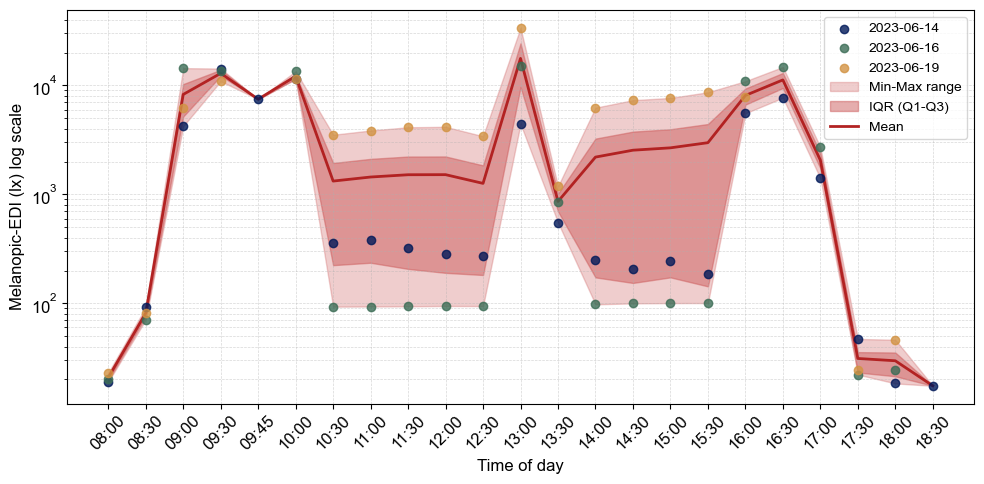

In [20]:
# Plot photopic illuminance for measurement days with central stats
fig, ax = plt.subplots(figsize=(10,5))

scatter_handles = []  # to collect scatter handles for legend
colors = [cm.batlow(i/len(copy_trajectory_canada_df['date'].unique())) for i in range(len(copy_trajectory_canada_df['date'].unique()))]

# Plot each day's measurements as scatter
for i, date in enumerate(copy_trajectory_canada_df['date'].unique()):
    day_data = copy_trajectory_canada_df[copy_trajectory_canada_df['date'] == date]
    sc = ax.scatter(
        [t.strftime('%H:%M') if not isinstance(t, str) else t[:5] for t in day_data['time']],
        day_data['X v,mel,D65 (MEDI) [lx]'],
        color=colors[i],
        alpha=0.8,
        zorder=4
    )
    scatter_handles.append((sc, str(date)))  # store handle + label


# Fill area between Q1 and Q3 (IQR)
iqr_fill = ax.fill_between(
    [t.strftime('%H:%M') for t in melanopic_stats['time']],
    melanopic_stats['q1'],
    melanopic_stats['q3'],
    color='indianred',
    alpha=0.5,
    zorder=1,
    label='IQR (Q1-Q3)'
)

# Fill area between min and max
minmax_fill = ax.fill_between(
    [t.strftime('%H:%M') for t in melanopic_stats['time']],
    melanopic_stats['min'],
    melanopic_stats['max'],
    color='indianred',
    alpha=0.3,
    zorder=0,
    label='Min-Max'
)

# Overlay mean lines
mean_line, = ax.plot(
    [t.strftime('%H:%M') for t in melanopic_stats['time']],
    melanopic_stats['mean'],
    color='firebrick',
    linewidth=2,
    label='Mean',
    zorder=3
)

# Create legend: one handle per day + fill + mean
handles = [h for h, l in scatter_handles] + [minmax_fill, iqr_fill, mean_line]
labels = [l for h, l in scatter_handles] + ['Min-Max range', 'IQR (Q1-Q3)', 'Mean']

ax.legend(handles=handles, labels=labels, loc='upper right', fontsize=10)

# Log scale
ax.set_yscale('log')

# Labels and title
ax.set_xlabel('Time of day')
ax.set_ylabel('Melanopic-EDI (lx) log scale')
#ax.set_title('Melanopic-EDI per day')

# Grid with minor lines
ax.grid(which='both', linestyle='--', linewidth=0.5, alpha=0.5, zorder=0)

# Format x-axis ticks
plt.xticks(rotation=45)
plt.tight_layout()
fig.savefig('../results/plots/melanopic_trajectory_days.pdf', bbox_inches='tight')
fig.savefig('../results/plots/melanopic_trajectory_days.png', bbox_inches='tight')

### Photopic illuminance vr Melanopic EDI

In [ ]:
# Pearson correlation coefficient

correlation_coefficient = trajectory_canada_df['Illuminance [lx] (CIE1931 2°)'].corr(trajectory_canada_df['X v,mel,D65 (MEDI) [lx]'])

print( f" Correlation Coefficient between mEDI and Illuminance from Jeti: {correlation_coefficient}")

In [ ]:
# Create a new column 'in/out' based on 'view'
trajectory_canada_df['in/out'] = trajectory_canada_df['view'].apply(lambda x: 'Outdoor' if x.startswith('Outdoor') else 'Indoor')


In [ ]:
# Calculate correlation coefficient for Indoor data

# Calculate correlation coefficient for Indoor data
indoor_data = trajectory_canada_df[trajectory_canada_df['in/out'] == 'Indoor']
correlation_indoor = indoor_data['Illuminance [lx] (CIE1931 2°)'].corr(indoor_data['X v,mel,D65 (MEDI) [lx]'])

# Calculate correlation coefficient for Outdoor data
outdoor_data = trajectory_canada_df[trajectory_canada_df['in/out'] == 'Outdoor']
correlation_outdoor = outdoor_data['Illuminance [lx] (CIE1931 2°)'].corr(outdoor_data['X v,mel,D65 (MEDI) [lx]'])

# Print the results
print(f"Correlation Coefficient for Indoor data: {correlation_indoor}")
print(f"Correlation Coefficient for Outdoor data: {correlation_outdoor}")

In [ ]:
# Plot mEDI for each day in one plot, log10 scale (Jeti)

# Get a colormap and normalize it based on the number of groups
  
norm = plt.Normalize(0, len(trajectory_canada_df['date'].unique()))

plt.figure(figsize = (10,7)) 

x_values = set()

for i, (group, group_df) in enumerate(trajectory_canada_df.groupby('date')):
    
    jeti_values = pd.to_numeric(group_df['X v,mel,D65 (MEDI) [lx]'], errors='coerce')
    
    color = cmap(norm(i))  # Get a color based on the index of the group
    plt.plot(group_df['time'], jeti_values, label=f'date_{group}', color=color)
    plt.scatter(group_df['time'], jeti_values, marker='o', color=color)
    
    # Collect unique x values with corresponding y values
    valid_x_values = group_df.loc[~np.isnan(jeti_values), 'time'].unique()
    x_values.update(valid_x_values)
    
# Convert set to a sorted list
x_values = sorted(x_values)
plt.xticks(x_values, rotation=45)
plt.yscale('log')    
plt.xlabel('Time')
plt.ylabel('log(mEDI [lx])')
plt.title('mEDI from Jeti in log scale')
plt.legend(loc='upper right');

#plt.savefig(f'results/trajectories/trajectory_plots/Jeti_mEDI_Trajectory.pdf',dpi = 600, bbox_inches='tight');

In [ ]:
# Plot illuminace and mEDI for each day in log scale (Jeti)

# Get a colormap and normalize it based on the number of groups
cmap_ill = mpl.colormaps['winter']  
cmap_medi = mpl.colormaps['autumn'] 
norm = plt.Normalize(0, len(trajectory_canada_df['date'].unique()))


for i, (group, group_df) in enumerate(trajectory_canada_df.groupby('date')):
    plt.figure(figsize = (8,5))  # Create a new figure for each group
    
    color_illuminance = cmap_ill(norm(i))

    color_medi = cmap_medi(norm(i))
        
    jeti_illuminance = pd.to_numeric(group_df['Illuminance [lx] (CIE1931 2°)'])
    
    plt.plot(group_df['time'], group_df['Illuminance [lx] (CIE1931 2°)'], label='Illuminance', color=color_illuminance)
    plt.scatter(group_df['time'], group_df['Illuminance [lx] (CIE1931 2°)'], marker='o', color=color_illuminance)
    
    jeti_medi = pd.to_numeric(group_df['X v,mel,D65 (MEDI) [lx]'], errors='coerce')
    
    plt.plot(group_df['time'], group_df['X v,mel,D65 (MEDI) [lx]'], label='mEDI', alpha = 0.8, color=color_medi)
    plt.scatter(group_df['time'], group_df['X v,mel,D65 (MEDI) [lx]'], marker='o', alpha = 0.8, color=color_medi)
    
    plt.yscale('log')
    plt.xlabel('Time')
    plt.xticks(rotation=45)
    plt.ylabel('log[lx]')
    plt.title(f'Photopic illuminance and mEDI from Jeti in log scale_date{group}')
    plt.legend(loc='upper right');

    # Adjust layout for better spacing
    plt.tight_layout()
    
    #plt.savefig(f'results/trajectories/trajectory_plots/Jeti_Trajectory_{group}.pdf', dpi = 600, bbox_inches="tight");

In [ ]:
# Plot illuminace and mEDI ratio in one plot for all days in one plot (Jeti)

# Get a colormap and normalize it based on the number of groups 
 
norm = plt.Normalize(0, len(trajectory_canada_df['date'].unique()))
plt.figure(figsize = (10,7))
x_values = set()

for i, (group, group_df) in enumerate(trajectory_canada_df.groupby('date')):
    
    illuminance_values = pd.to_numeric(group_df['Illuminance [lx] (CIE1931 2°)'])
    medi_values = pd.to_numeric(group_df['X v,mel,D65 (MEDI) [lx]'], errors='coerce')
    ratio_values = illuminance_values / medi_values
    
    color = cmap(norm(i))
    
    plt.plot(group_df['time'], ratio_values, label=f'date_{group}', color=color)
    plt.scatter(group_df['time'], ratio_values, marker='o', color=color)
    # Collect unique x values with corresponding y values
    valid_x_values = group_df.loc[~np.isnan(ratio_values), 'time'].unique()
    x_values.update(valid_x_values)
    
# Convert set to a sorted list
x_values = sorted(x_values)
plt.xticks(x_values, rotation=45)
      
plt.xlabel('Time')
plt.ylabel('Ratio (illuminance/mEDI)')
plt.title('Photopic illuminance and mEDI ratio from Jeti')
plt.legend(loc='upper center');

# Adjust layout for better spacing
plt.tight_layout()

#plt.savefig(f'results/trajectories/trajectory_plots/Jeti_Trajectory_ratio.pdf', dpi = 600, bbox_inches="tight");

In [ ]:
# Plot illumnance vr mEDI for all trajectory days in one plot (Jeti)

plt.figure(figsize=(6, 6)) 
for group, group_df in trajectory_canada_df.groupby('date'):
    # Drop rows with NaN values in the specified columns
    group_df = group_df.dropna(subset=['X v,mel,D65 (MEDI) [lx]', 'Illuminance [lx] (CIE1931 2°)'])
    
    x_values = group_df['X v,mel,D65 (MEDI) [lx]'].values.reshape(-1, 1)
    y_values = group_df['Illuminance [lx] (CIE1931 2°)'].values
    
    scatter_plot = plt.scatter(x_values, y_values, label=group)
    

# Perform linear regression for y = mx + b
model = LinearRegression()
model.fit(x_values, y_values)
    
# Get regression line parameters
m = model.coef_[0]
b = model.intercept_

# Generate x values for the regression line
regression_line_x = np.linspace(0, x_values, 100).reshape(-1, 1)
    
# Calculate corresponding y values for the regression line
regression_line_y = m * regression_line_x + b
    
# Plot the regression line
plt.plot(regression_line_x, regression_line_y, color='black', label=f'y = {m:.2f}x + {b:.2f}')

# Perform linear regression for y = m2x
model_new = LinearRegression()
model_new.fit(x_values, y_values)

# Get regression line parameters for the new line
m2 = model_new.coef_[0]

# Calculate corresponding y values for the new regression line (y = mx)
regression_line_y_new = m2 * regression_line_x

# Plot the new regression line
plt.plot(regression_line_x, regression_line_y_new, color='red', label=f'y = {m:.2f}x')
    
# Set limits based on the current plot's maximum value
plt.xlim(0)
plt.ylim(0)
plt.xlabel('mEDI [lx]')
plt.ylabel('Illuminance [lx]')
plt.legend(loc = 'upper left')
plt.title(f'Illuminance vr mEDI for trajectory days');


In [ ]:

plt.figure(figsize=(6, 6)) 
for group, group_df in trajectory_canada_df.groupby('date'):
    group_df = group_df.dropna(subset=['X v,mel,D65 (MEDI) [lx]', 'Illuminance [lx] (CIE1931 2°)'])
    
    x_values = group_df['X v,mel,D65 (MEDI) [lx]'].values.reshape(-1, 1)
    y_values = group_df['Illuminance [lx] (CIE1931 2°)'].values
    max_value = y_values.max()
    
    scatter_plot = plt.scatter(x_values, y_values, label=group)

# Perform linear regression for log-transformed values
model = LinearRegression()
model.fit(np.log10(x_values), np.log10(y_values))
    
    # Get regression line parameters
m = model.coef_[0]
b = model.intercept_

    # Generate log-transformed x values for the regression line
regression_line_x = np.linspace(x_values.min(), x_values.max(), 100)
regression_line_x_log = np.log10(regression_line_x)    
# Calculate corresponding log-transformed y values for the regression line
regression_line_y_log = m * regression_line_x_log + b
regression_line_y = 10 ** regression_line_y_log
# Plot the regression line
plt.plot(regression_line_x, regression_line_y, color='black', label=f'log fit, y = {b:.2f}+ {m:.2f}x')

# Perform linear regression for y = m2x
model_new = LinearRegression()
model_new.fit(np.log10(x_values), np.log10(y_values))

# Get regression line parameters for the new line
m2 = model_new.coef_[0]

# Calculate corresponding y values for the new regression line (y = mx)
regression_line_y_new = m2 * regression_line_x

# Plot the new regression line
plt.plot(regression_line_x, regression_line_y_new, color='red', label=f'log fit, y = {m2:.2f}x')



plt.xscale('log')  # Set x-axis to log scale
plt.yscale('log')  # Set y-axis to log scale

plt.xlabel('log(mEDI [lx])')
plt.ylabel('log(Illuminance [lx])')
plt.legend(loc='upper left')
plt.grid(True, which='minor', linestyle='--', linewidth=0.5)
plt.title(f'Illuminance vr mEDI in log 10 for trajectory days');


#plt.savefig(f'results/trajectories/trajectory_plots/Jeti_Illuminance_vr_mEDI.pdf', dpi = 600, bbox_inches='tight');

In [ ]:
# Create subplots for two groups
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

for (group, group_df), ax in zip(trajectory_canada_df.groupby('in/out'), [ax1, ax2]):
    group_df = group_df.dropna(subset=['X v,mel,D65 (MEDI) [lx]', 'Illuminance [lx] (CIE1931 2°)'])
    
    x_values = group_df['X v,mel,D65 (MEDI) [lx]'].values.reshape(-1, 1)
    y_values = group_df['Illuminance [lx] (CIE1931 2°)'].values
    max_value = y_values.max()
    
    scatter_plot = ax.scatter(x_values, y_values, label=group)

    # Perform linear regression for log-transformed values
    model = LinearRegression()
    model.fit(np.log10(x_values), np.log10(y_values))
    
    # Get regression line parameters
    m = model.coef_[0]
    b = model.intercept_

    # Generate log-transformed x values for the regression line
    regression_line_x = np.linspace(x_values.min(), x_values.max(), 100).reshape(-1, 1)
    regression_line_x_log = np.log10(regression_line_x)    
    # Calculate corresponding log-transformed y values for the regression line
    regression_line_y_log = m * regression_line_x_log + b
    regression_line_y = 10 ** regression_line_y_log
    # Plot the regression line
    ax.plot(regression_line_x, regression_line_y, color='black', label=f'logaritmic fit, y = {b:.2f}+ {m:.2f}x')

    # Perform linear regression for y = m2x
    model_new = LinearRegression()
    model_new.fit(np.log10(x_values), np.log10(y_values))

    # Get regression line parameters for the new line
    m2 = model_new.coef_[0]

    # Calculate corresponding y values for the new regression line (y = mx)
    regression_line_y_new = m2 * regression_line_x

    # Plot the new regression line
    ax.plot(regression_line_x, regression_line_y_new, color='red', label=f'logaritmic fit, y = {m2:.2f}x')

    ax.set_xscale('log')  # Set x-axis to log scale
    ax.set_yscale('log')  # Set y-axis to log scale

    ax.set_xlabel('log(mEDI [lx])')
    ax.set_ylabel('log(Illuminance [lx])')
    ax.legend(loc='upper left')
    ax.grid(True, which='minor', linestyle='--', linewidth=0.5)
    ax.set_title(f'Illuminance vs mEDI for {group} trajectory days')
    # Set x and y limits explicitly
    ax.set_xlim(10, 1e5)
    ax.set_ylim(10, 1e5)
plt.tight_layout()

#plt.savefig('results/trajectories/trajectory_plots/Jeti_Illuminance_vr_mEDI_inout.pdf', dpi = 600, bbox_inches='tight');

## Next step: Now I want table for fit and error. Not correct, will check it later

In [ ]:
# Select the columns of interest
x_column = 'X v,mel,D65 (MEDI) [lx]'
y_column = 'Illuminance [lx] (CIE1931 2°)'

# Drop NaN values from the selected columns
cleaned_df = trajectory_canada_df[[x_column, y_column]].dropna()

In [ ]:

# Perform linear regression for y = mx + b
tidy_trajectory_canada_df = trajectory_canada_df.dropna(subset=['X v,mel,D65 (MEDI) [lx]', 'Illuminance [lx] (CIE1931 2°)'])

x_values = tidy_trajectory_canada_df['X v,mel,D65 (MEDI) [lx]'].values.reshape(-1, 1)
y_values = tidy_trajectory_canada_df['Illuminance [lx] (CIE1931 2°)'].values

model = LinearRegression()
model.fit(x_values, y_values)
    
# Get regression line parameters
slope = model.coef_[0]
intercept = model.intercept_

# Calculate variance (mean squared error)
predictions = model.predict(x_values)
variance = mean_squared_error(y_values, predictions)

print(f"Slope: {slope:.2f}")
print(f"Intercept: {intercept:.2f}")
print (f'y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}')
print(f"Variance (Mean Squared Error): {variance:.2f}")

In [ ]:
# Select the columns of interest
x_column = 'X v,mel,D65 (MEDI) [lx]'
y_column = 'Illuminance [lx] (CIE1931 2°)'

# Drop NaN values from the selected columns
tidy_trajectory_canada_df = tidy_trajectory_canada_df.dropna(subset=[x_column, y_column, 'in/out'])

# Group by 'in/out' and perform linear regression for each group
for group, group_df in tidy_trajectory_canada_df.groupby('in/out'):
    # Extract the x and y values for the current group
    x_values = group_df[x_column].values.reshape(-1, 1)
    y_values = group_df[y_column].values

    # Perform linear regression
    model = LinearRegression()
    model.fit(x_values, y_values)

    # Get regression line parameters
    slope = model.coef_[0]
    intercept = model.intercept_

    # Calculate variance (mean squared error)
    predictions = model.predict(x_values)
    variance = mean_squared_error(y_values, predictions)

    print(f"Group: {group}")
    print(f"Slope: {slope:.2f}")
    print(f"Intercept: {intercept:.2f}")
    print(f'y = {slope:.2f}x + {intercept:.2f}')
    print(f"Variance (Mean Squared Error): {variance:.2f}")
    print()

In [ ]:
tidy_trajectory_canada_df

In [ ]:
# Calculate the number of combinations
n = 63
r = 21
num_combinations = math.comb(n, r)

# Print the result
print(f"The number of possible combinations is: {num_combinations}")

In [ ]:
# Calculate the number of combinations
n = 63
r = 8
num_combinations = math.comb(n, r)

# Print the result
print(f"The number of possible combinations is: {num_combinations}")

## Trajectory models, synthetic sequences


In [21]:
# Define the trajectory bins as placeholders for the synthetic days (22 time slots)
placeholders = ['MH01', 'MH02', 'MC03', 'MC04', 'MC05', 'MO06', 'MO07', 'MO08', 'MO09', 'MO10', 'NN11', 'NN12', 'AO13', 'AO14', 'AO15', 'AO16', 'AC17', 'AC18', 'AC19', 'AH20', 'AH21', 'AH22']
len(placeholders)

22

In [22]:
def plot_monte_carlo_stability_bar_multi(sequences, repeats=[1000, 10000, 100000],
                                   rel_threshold=0.01, metric_name='Melanopic-EDI',
                                   sequences_name=None, placeholders=None):
    """
    Plot Monte Carlo stability for each placeholder as grouped bar plot for multiple repeat subsamples,
    adding statistical info (p-values and mean) to the legend and stars for significance.
    
    sequences : np.array, shape (n_slots, n_sequences)
    repeats : list of int, number of sequences to sample for each Monte Carlo repeat
    placeholders : list of names for placeholders (assumed fixed)
    """
    n_slots, n_sequences = sequences.shape
    n_repeats = len(repeats)
    
    # Color palette
    colors = [cm.batlow(i / n_repeats) for i in range(n_repeats)]
    
    # X positions
    width = 0.25
    x = np.arange(n_slots)
    
    fig, ax = plt.subplots(figsize=(16,6))
    
    all_rel_changes = []
    all_p_values = []
    
    mean_full = sequences.mean(axis=1)
    std_full = sequences.std(axis=1, ddof=1)
    
    for i, r in enumerate(repeats):
        # Limit r to number of sequences
        r_actual = min(r, n_sequences)
        pct_idx = int(r_actual * 0.75)
        
        # Subset of sequences for this repeat
        seq_sample = sequences[:, :r_actual]
        mean_75 = seq_sample[:, :pct_idx].mean(axis=1)
        
        # Relative change
        rel_change_mean = np.abs(mean_full - mean_75) / (mean_full + 1e-8)
        all_rel_changes.append(rel_change_mean)
        
        # p-values for each placeholder
        _, p_vals = ttest_1samp(rel_change_mean, rel_threshold)
        all_p_values.append(p_vals)
        
        # Plot bars
        bars = ax.bar(x + i*width, rel_change_mean*100, width=width, color=colors[i], alpha=0.8)
        
        # Annotate stars based on significance
        for xi, val, p in zip(x + i*width, rel_change_mean*100, [p_vals]*len(rel_change_mean)):
            # Determine significance level
            if p < 0.001:
                star = '***'
            elif p < 0.01:
                star = '**'
            elif p < 0.05:
                star = '*'
            else:
                star = ''
            ax.text(xi, val + 0.05, star, ha='center', va='bottom', fontsize=10, color='black')
    
    # Threshold line
    ax.axhline(rel_threshold*100, color='firebrick', linestyle='--', label=f'Threshold {rel_threshold*100:.1f}%')
    
    # Add legend info: mean + p-value across all placeholders per repeat
    for i, r in enumerate(repeats):
        rel = all_rel_changes[i]
        # One-sample t-test across all placeholders
        _, p_val_all = ttest_1samp(rel, rel_threshold)
        mean_all = rel.mean() * 100
        ax.bar(0,0, color=colors[i], alpha=0.8, label=f'{r} repeats: mean={mean_all:.2f}%, p={p_val_all:.3f}')
    
    ax.set_xticks(x + width*(n_repeats-1)/2)
    ax.set_xticklabels(placeholders, rotation=45)
    ax.set_ylabel(f'Relative change in mean {metric_name} (%)')
    ax.set_title('Monte Carlo stability per placeholder for multiple repeats')
    ax.legend(loc='upper right')
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    
    # Save plot
    frame = inspect.currentframe()
    args, _, _, values = inspect.getargvalues(frame.f_back)
    first_arg_name = args[0] if args else "sequence"
    
    filename_base = f"../results/plots/MonteCarlo_stability_{sequences_name}"
    fig.savefig(f"{filename_base}.pdf", bbox_inches='tight')
    fig.savefig(f"{filename_base}.png", bbox_inches='tight', dpi=300)
    
    return all_rel_changes, all_p_values, mean_full, std_full

In [23]:
# A function to create several bundles of different sequences and evaluate the  Monte Carlo stability.
# If the mean values for all place holders are stable (relative changes are less than 1%, the random sampling size is justified.)
def plot_monte_carlo_stability_bar(sequences, placeholders=None, rel_threshold=0.01, metric_name='Melanopic-EDI', sequences_name=None):
    """
    Plot Monte Carlo stability for each placeholder as bar plot with relative change metrics.
    
    sequences : np.array, shape = (n_slots, n_sequences)
    placeholders : list of names for placeholders (default: range(n_slots))
    rel_threshold : float, threshold to consider sampling stable (e.g., 0.01 = 1%)
    metric_name : str, used for y-axis label
    """
    n_slots, n_sequences = sequences.shape
    if placeholders is None:
        placeholders = [f'ph{i+1}' for i in range(n_slots)]
    
    # Compute mean and std using 75% of sequences vs all sequences
    pct_idx = int(n_sequences * 0.75)  # 75% index
    mean_full = sequences.mean(axis=1)
    std_full = sequences.std(axis=1, ddof=1)
    mean_75 = sequences[:, :pct_idx].mean(axis=1)
    std_75 = sequences[:, :pct_idx].std(axis=1, ddof=1)
    
    # Relative changes
    rel_change_mean = np.abs(mean_full - mean_75) / (mean_full + 1e-8)
    rel_change_std = np.abs(std_full - std_75) / (std_full + 1e-8)
    
    # Plot bar plot for mean relative change
    x = np.arange(n_slots)
    fig, ax = plt.subplots(figsize=(12,5))
    bars = ax.bar(x, rel_change_mean*100, color='skyblue', alpha=0.8)
    
    # Threshold line
    plt.axhline(rel_threshold*100, color='red', linestyle='--', label=f'Threshold {rel_threshold*100:.1f}%')
    
    # Annotate bars with values
    for bar, val in zip(bars, rel_change_mean*100):
        plt.text(bar.get_x() + bar.get_width()/2, val + 0.1, f'{val:.2f}%', ha='center', va='bottom', fontsize=8)

    plt.xticks(x, placeholders, rotation=45)
    plt.ylabel(f'Relative change in mean {metric_name} (%)')
    plt.title(f'Monte Carlo stability per placeholder')
    plt.legend(loc= 'upper right')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()

    # Inside your function, replace the saving part with:
    frame = inspect.currentframe()
    args, _, _, values = inspect.getargvalues(frame.f_back)
    # Get the first argument name from the caller's frame
    first_arg_name = args[0] if args else "sequence"
    
    filename_base = f"../results/plots/MonteCarlo_stability_{sequences_name}"
    fig.savefig(f"{filename_base}.pdf", bbox_inches='tight')
    fig.savefig(f"{filename_base}.png", bbox_inches='tight', dpi=300)
    
    # Return metrics for further reporting if needed
    return rel_change_mean, rel_change_std, mean_full, std_full

### Naive model

In [24]:
# 100000 sequence, random sampling with permutation of 63 melanopic-EDI values in 22 placeholders. 

np.random.seed(20)
n_sequences = 100000  # number of synthetic sequences
n_slots = len(placeholders)

# Extract metric and clean it
melanopic_values = copy_trajectory_canada_df['X v,mel,D65 (MEDI) [lx]'].dropna().values

# Generate all sequences at once
naive_sequences = np.array([np.random.choice(melanopic_values, size=n_slots) 
                          for _ in range(n_sequences)]).T 

# Create DataFrame in one shot
naive_synthetic_df = pd.DataFrame(naive_sequences, index=placeholders,
                            columns=[f'seq_{i+1:04d}' for i in range(n_sequences)])

# synthetic_df now has placeholders as index and sequences as columns
print(naive_synthetic_df.shape)
naive_synthetic_df.iloc[:, :10].head()


(22, 100000)


,seq_0001,seq_0002,seq_0003,seq_0004,seq_0005,seq_0006,seq_0007,seq_0008,seq_0009,seq_0010
MH01,97.9,100.6,93.9,93.5,355.0,11466.1,100.6,11539.1,14772.3,4227.6
MH02,13535.0,100.6,6155.2,81.1,13535.0,1408.0,22.2,4227.6,4439.6,1408.0
MC03,245.8,46.3,94.3,355.0,245.8,4171.3,10945.2,7325.8,11539.1,17.5
MC04,94.5,185.7,269.7,207.8,7709.9,11466.1,2715.7,20.4,19.0,81.1
MC05,93.2,2715.7,24.4,70.8,207.8,24.2,20.4,94.5,7678.2,18.4


In [25]:
naive_synthetic_df.to_csv(r'..\results\naive_melanopic_sequence.csv')

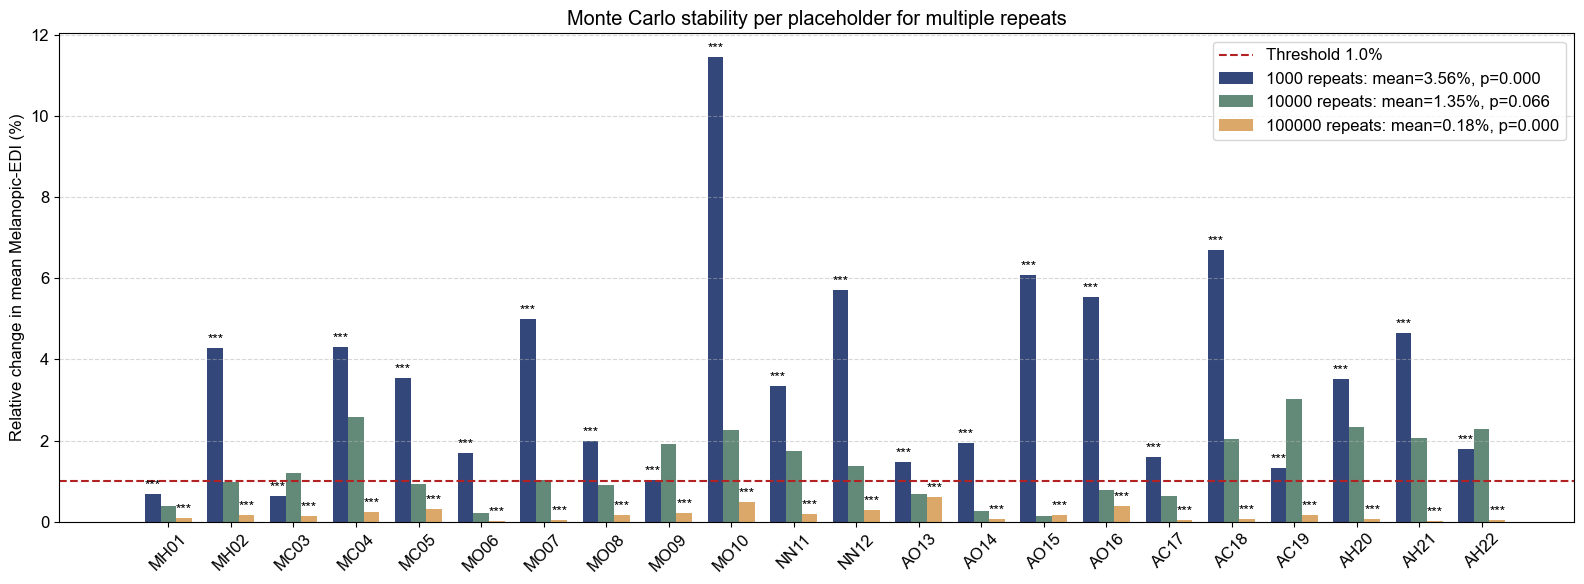

In [26]:
rel_mean, rel_std, mean_vals, std_vals = plot_monte_carlo_stability_bar_multi(
    naive_sequences, placeholders=placeholders, rel_threshold=0.01, sequences_name= 'naive'
)


### Naive indoor model

In [27]:
# 100000 sequence, random sampling with permutation of 20 melanopic-EDI values in 22 placeholders.
np.random.seed(20)
# Number of synthetic sequences
n_sequences = 100000
n_slots = len(placeholders)

# 1. Filter indoor values
indoor_df = copy_trajectory_canada_df[copy_trajectory_canada_df['view'].str.contains('Indoor', na=False)]

# 2. Extract melanopic values from indoor data only
indoor_melanopic = indoor_df['X v,mel,D65 (MEDI) [lx]'].dropna().values

# 3. Generate sequences: randomly draw indoor values into all placeholders
indoor_sequences = np.array([
    np.random.choice(indoor_melanopic, size=n_slots)
    for _ in range(n_sequences)
]).T   # shape: (22, n_sequences)

# 4. Create synthetic DataFrame
indoor_synthetic_df = pd.DataFrame(
    indoor_sequences,
    index=placeholders,
    columns=[f'seq_{i+1:04d}' for i in range(n_sequences)]
)
print(indoor_synthetic_df.shape)
indoor_synthetic_df.iloc[:, :10].head()

(22, 100000)


,seq_0001,seq_0002,seq_0003,seq_0004,seq_0005,seq_0006,seq_0007,seq_0008,seq_0009,seq_0010
MH01,4130.5,7678.2,355.0,286.4,23.0,18.4,320.2,97.9,24.2,93.5
MH02,100.5,3421.9,47.1,7678.2,4171.3,81.1,19.0,245.8,94.3,7325.8
MC03,17.5,269.7,70.8,94.3,551.7,17.5,94.3,92.0,17.5,245.8
MC04,81.1,3421.9,24.2,18.4,93.5,100.6,3421.9,7678.2,269.7,286.4
MC05,22.2,3858.5,20.4,378.2,81.1,46.3,378.2,93.2,245.8,3527.1


In [28]:
indoor_synthetic_df.to_csv(r'..\results\naive_indoor_melanopic_sequence.csv')

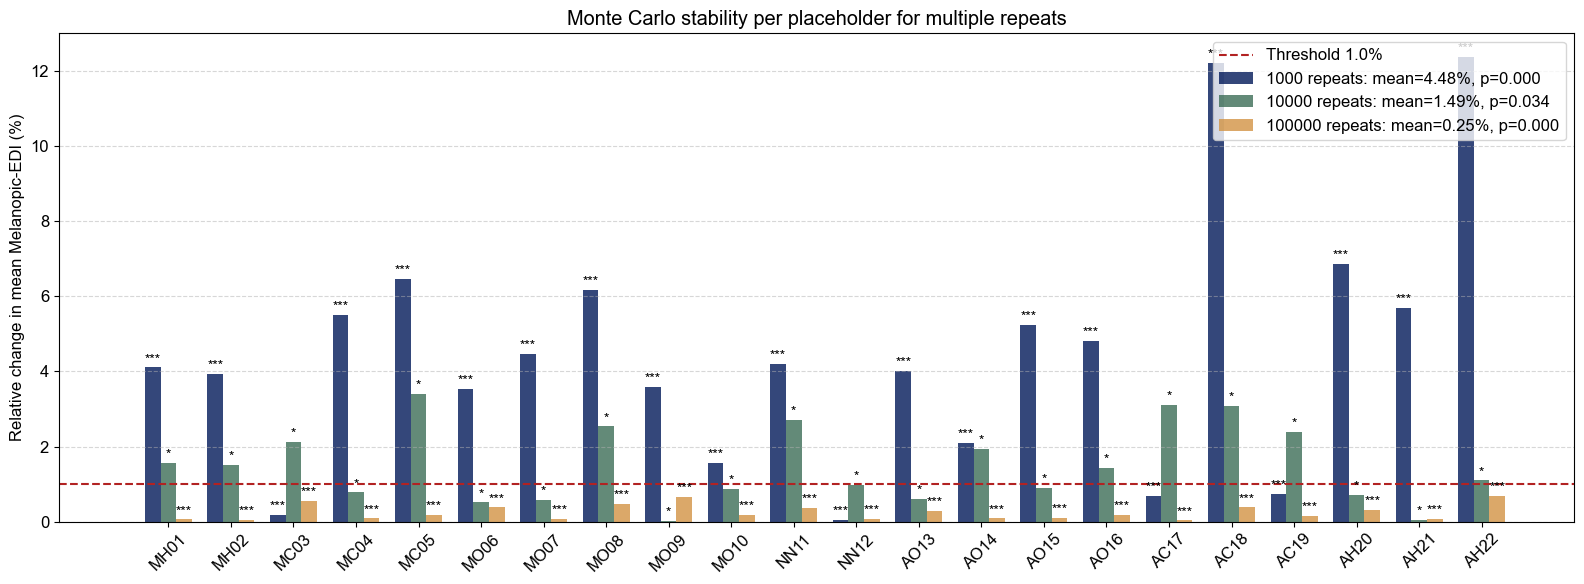

In [29]:
rel_mean, rel_std, mean_vals, std_vals = plot_monte_carlo_stability_bar_multi(
    indoor_sequences, placeholders=placeholders, rel_threshold=0.01, sequences_name= 'naive_indoor'
)

### Naive outdoor model

In [30]:
# 100000 sequence, random sampling with permutation of 43 melanopic-EDI values in 22 placeholders.
n_sequences = 100000
n_slots = len(placeholders)

# 1. Filter indoor values
outdoor_df = copy_trajectory_canada_df[copy_trajectory_canada_df['view'].str.contains('Outdoor', na=False)]

# 2. Extract melanopic values from indoor data only
outdoor_melanopic = outdoor_df['X v,mel,D65 (MEDI) [lx]'].dropna().values

# 3. Generate sequences: randomly draw indoor values into all placeholders
outdoor_sequences = np.array([
    np.random.choice(outdoor_melanopic, size=n_slots)
    for _ in range(n_sequences)
]).T   # shape: (22, n_sequences)

# 4. Create synthetic DataFrame
outdoor_synthetic_df = pd.DataFrame(
    outdoor_sequences,
    index=placeholders,
    columns=[f'seq_{i+1:04d}' for i in range(n_sequences)]
)
print(outdoor_synthetic_df.shape)
outdoor_synthetic_df.iloc[:, :10].head()

(22, 100000)


,seq_0001,seq_0002,seq_0003,seq_0004,seq_0005,seq_0006,seq_0007,seq_0008,seq_0009,seq_0010
MH01,14421.8,10945.2,1408.0,2715.7,14772.3,4227.6,10942.8,4227.6,13535.0,13535.0
MH02,4227.6,10942.8,2715.7,14772.3,14772.3,11539.1,13503.6,4439.6,33750.6,1408.0
MC03,2715.7,2715.7,10942.8,14287.4,14421.8,10942.8,14287.4,13535.0,7709.9,4439.6
MC04,10942.8,13503.6,14287.4,1408.0,14287.4,14287.4,10945.2,14938.9,14287.4,14938.9
MC05,10945.2,4439.6,10942.8,33750.6,13535.0,4227.6,13503.6,33750.6,7709.9,14938.9


In [31]:
outdoor_synthetic_df.to_csv(r'..\results\naive_outdoor_melanopic_sequence.csv')

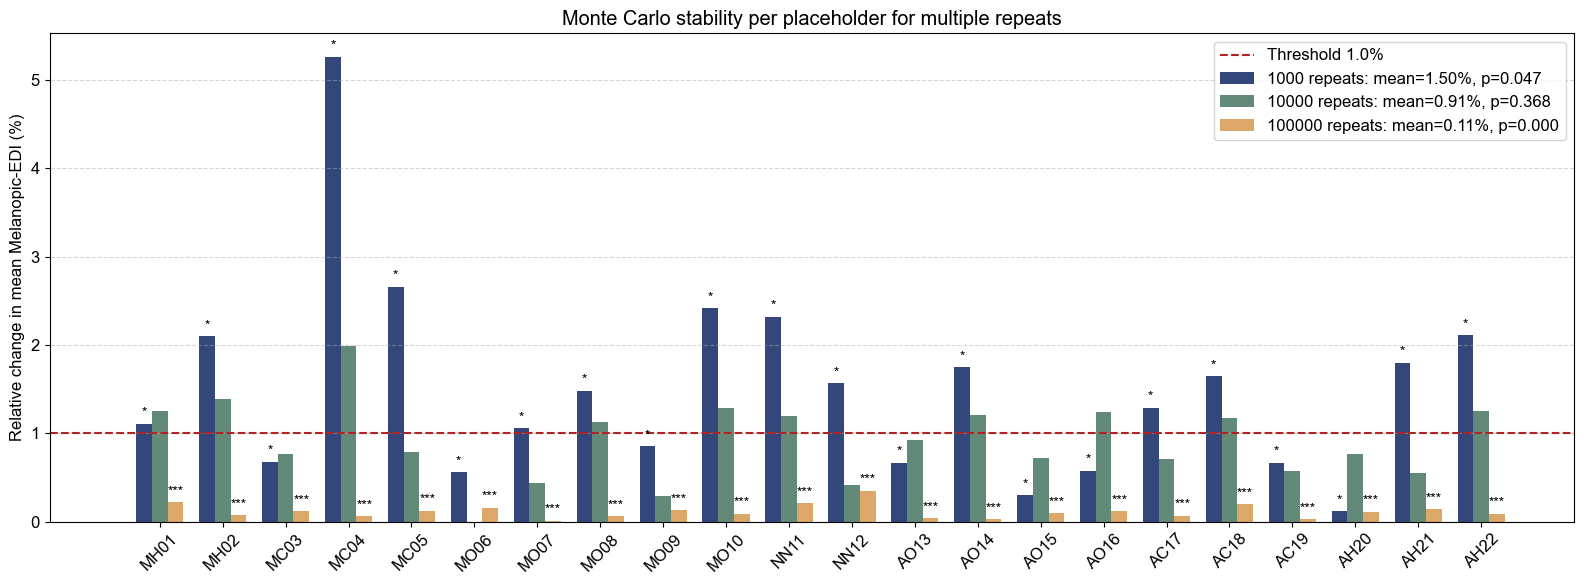

In [32]:
rel_mean, rel_std, mean_vals, std_vals = plot_monte_carlo_stability_bar_multi(
    outdoor_sequences, placeholders=placeholders, rel_threshold=0.01, sequences_name= 'naive_outdoor'
)

### Time restricted model

In [ ]:
df = copy_trajectory_canada_df.copy()
df['datetime'] = pd.to_datetime(df['datetime'])  

# create 22 fixed half-hour bin starts from 07:59 for mid measured day
bin_starts = pd.date_range("2023-06-16 07:59", periods=22, freq="30min").time

# collect values per bin (no new df columns)
mel_bins = []
for start in bin_starts:
    end = (pd.Timestamp("2000-01-01 " + start.strftime("%H:%M")) + pd.Timedelta(minutes=30)).time()
    mask = (df['datetime'].dt.time >= start) & (df['datetime'].dt.time < end)
    vals = df.loc[mask, 'X v,mel,D65 (MEDI) [lx]'].dropna().values
    mel_bins.append(vals)

In [34]:
n_sequences = 100000
n_slots = len(mel_bins)   # should be 22

# Generate sequences: one random value from bin i → placeholder i
time_restricted_sequences = np.zeros((n_slots, n_sequences))

for i, bin_values in enumerate(mel_bins):
    bin_values = np.array(bin_values)
    if len(bin_values) == 0:
        raise ValueError(f"Bin {i} is empty. Cannot sample.")
    time_restricted_sequences[i] = np.random.choice(bin_values, size=n_sequences, replace=True)

# Create DataFrame
time_restricted_df = pd.DataFrame(
    time_restricted_sequences,
    index=placeholders, 
    columns=[f"seq_{i+1:04d}" for i in range(n_sequences)]
)
print(time_restricted_df.shape)
time_restricted_df.iloc[:, :10].head()

(22, 100000)


,seq_0001,seq_0002,seq_0003,seq_0004,seq_0005,seq_0006,seq_0007,seq_0008,seq_0009,seq_0010
MH01,19.0,19.0,20.4,23.0,19.0,19.0,20.4,23.0,19.0,23.0
MH02,70.8,81.1,92.0,92.0,92.0,70.8,70.8,70.8,92.0,81.1
MC03,6155.2,6155.2,6155.2,4227.6,4227.6,4227.6,4227.6,6155.2,6155.2,14421.8
MC04,10942.8,13535.0,10942.8,13535.0,13535.0,10942.8,7474.6,10942.8,10942.8,7474.6
MC05,11466.1,11539.1,11539.1,11539.1,13503.6,13503.6,11539.1,13503.6,13503.6,11466.1


In [35]:
time_restricted_df.to_csv(r'..\results\time_restricted_melanopic_sequence.csv')

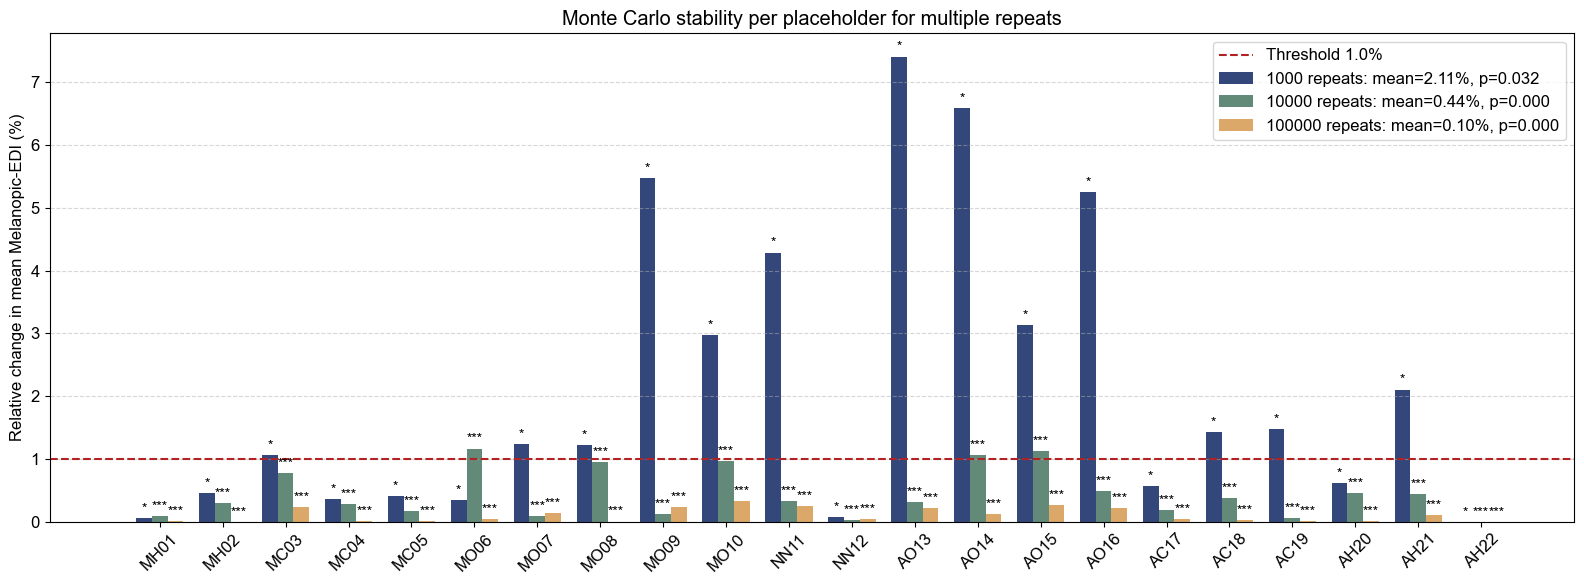

In [36]:
rel_mean, rel_std, mean_vals, std_vals = plot_monte_carlo_stability_bar_multi(
    time_restricted_sequences, placeholders=placeholders, rel_threshold=0.01, sequences_name= 'time_restricted'
)

### Location restricted model

In [45]:

# Extract hour + minute as float for easier comparison
df['hour_min'] = df['datetime'].dt.hour * 100 + df['datetime'].dt.minute

# Create empty column for placeholder group
df['location_group'] = ''

# Morning (before 12.99 ~ 12:59)
morning_mask = df['hour_min'] <= 1259
afternoon_mask = df['hour_min'] >= 1359
noon_mask = (df['hour_min'] > 1259) & (df['hour_min'] < 1359)

# Morning placeholders
df.loc[morning_mask & df['scene'].str.contains('Indoor') & ~df['scene'].str.contains('office', case=False),
       'location_group'] = 'MH'  # Morning Home
df.loc[morning_mask & df['scene'].str.contains('Indoor') & df['scene'].str.contains('office', case=False),
       'location_group'] = 'MO'  # Morning Office
df.loc[morning_mask & df['scene'].str.contains('Outdoor'),
       'location_group'] = 'MC'  # Morning Commute

# Afternoon placeholders
df.loc[afternoon_mask & df['scene'].str.contains('Indoor') & ~df['scene'].str.contains('office', case=False),
       'location_group'] = 'AH'  # Afternoon Home
df.loc[afternoon_mask & df['scene'].str.contains('Indoor') & df['scene'].str.contains('office', case=False),
       'location_group'] = 'AO'  # Afternoon Office
df.loc[afternoon_mask & df['scene'].str.contains('Outdoor'),
       'location_group'] = 'AC'  # Afternoon Commute

# Noon placeholders
df.loc[noon_mask, 'location_group'] = 'NN'  # Noon

In [46]:
# Extract melanopic values per activity category
group_to_values = {}

for g in ['MH','MO','MC','AH','AO','AC','NN']:
    vals = df.loc[df['location_group'] == g, 'X v,mel,D65 (MEDI) [lx]'].dropna().values
    group_to_values[g] = vals.astype(float)
# Merge categories based on your mapping
location_map = {
    'H': ['MH', 'AH'],    # Home
    'O': ['MO', 'AO'],    # Office
    'C': ['MC', 'AC'],    # Commute
    'N': ['NN']           # Noon
}
# Build final pools
location_pool = {}
for key, groups in activity_map.items():
    merged = np.concatenate([group_to_values[g] for g in groups if len(group_to_values[g]) > 0])
    location_pool[key] = merged

In [52]:
n_sequences = 100000  # number of synthetic sequences
outfile = r"..\results\location_restricted_melanopic_sequence.csv"
# Map each placeholder to its activity type (second character)
placeholder_location = []
for ph in placeholders:
    if ph[:2] == 'NN':  # noon placeholders
        placeholder_location.append('N')
    else:
        placeholder_location.append(ph[1])  # H, O, C

# Initialize matrix
location_restricted_sequence = np.zeros((len(placeholders), n_sequences))

# Fill each placeholder row from the merged activity pool
for i, loc in enumerate(placeholder_location):
    pool = location_pool[loc]  # H, O, C, or N
    location_restricted_sequence[i, :] = np.random.choice(pool, size=n_sequences)

# Convert to DataFrame
location_restricted_df = pd.DataFrame(location_restricted_sequence, index=placeholders,
                      columns=[f"seq_{i+1:05d}" for i in range(n_sequences)])

# Save CSV
location_restricted_df.to_csv(outfile)
print("Done.")

Done.


In [44]:
# Monte carlo function and plot but need to find the correct sequence 

### Time/location restricted model

In [48]:
# All time-activity groups in your labeling scheme
codes = ['MH','MO','MC','AH','AO','AC','NN']

time_location_pool = {}
for code in codes:
    vals = df.loc[df['location_group'] == code,
                  'X v,mel,D65 (MEDI) [lx]'].dropna().values
    time_location_pool[code] = vals.astype(float)


In [51]:
n_sequences = 100000
chunk_size = 1000
outfile = r"..\results\time_location_restricted_melanopic_sequence.csv"

# Each placeholder draws from its exact pool (AO → AO, MH → MH, etc.)
time_location_sequence = np.zeros((len(placeholders), n_sequences))

for i, ph in enumerate(placeholders):
    pool = time_location_pool[ph[:2]]  # first two letters = time + activity
    time_location_sequence[i, :] = np.random.choice(pool, size=n_sequences)

# Convert to DataFrame: rows = placeholders, columns = sequences
time_location_restricted_df = pd.DataFrame(time_location_sequence, index=placeholders,
                      columns=[f"seq_{i+1:05d}" for i in range(n_sequences)])

# Save to CSV
time_location_restricted_df .to_csv(outfile)
print("Done.")

Done.


In [ ]:
df_chunk.shape

In [ ]:
rel_mean, rel_std, mean_vals, std_vals = plot_monte_carlo_stability_bar_multi(
    time_restricted_sequences, placeholders=placeholders, rel_threshold=0.01, sequences_name= 'time_restricted'
)